R0     = 10.00
I_c    = 90.91
delta* = 0.0900
p*     = 0.90


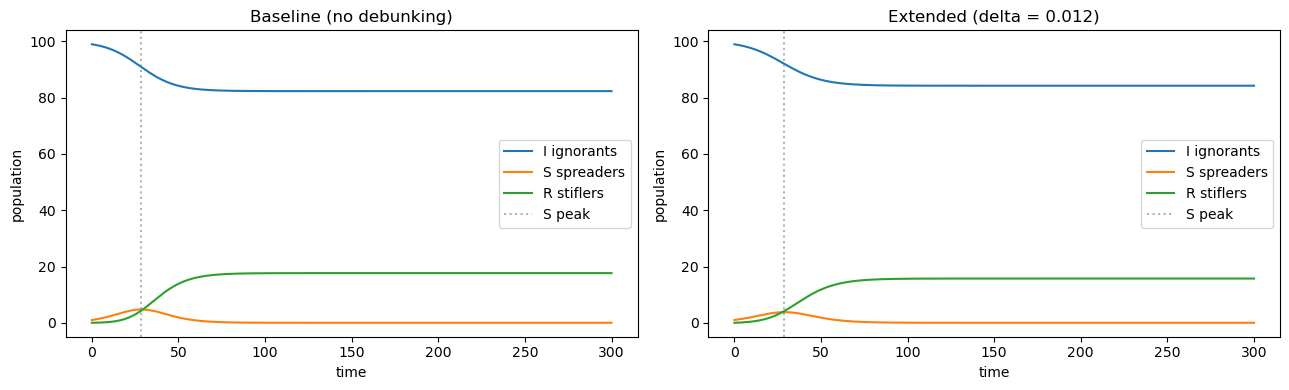

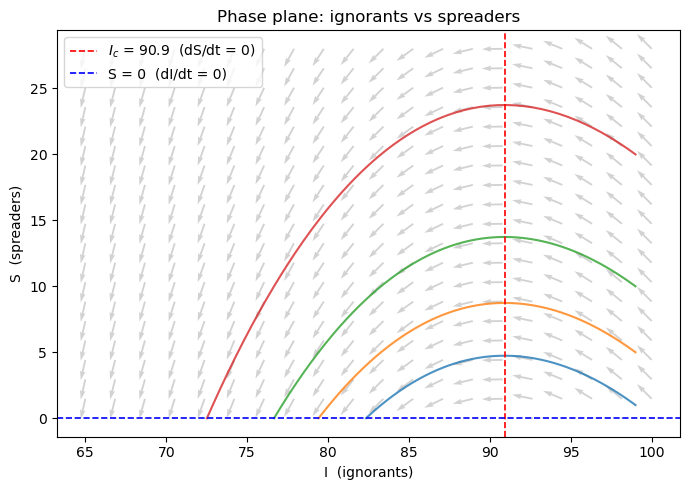

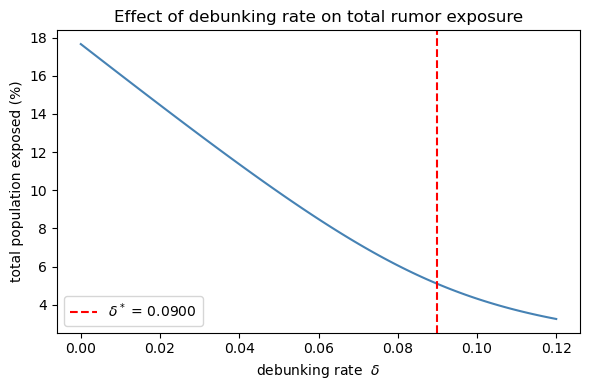

In [ ]:
import numpy as np
from scipy.integrate import solve_ivp
import matplotlib.pyplot as plt

# parameters - pick values so R0 > 1 (rumor spreads)
beta  = 0.001    # spreading rate
alpha = 0.01     # stifling rate
delta = 0.012    # debunking rate, below delta* to show partial intervention
N     = 100      # total population

R0     = beta * N / alpha   # = 10.0
Ic     = alpha * N / (alpha + beta)  # = 90.9
d_star = beta * N - alpha  # = 0.09
p_star = 1 - 1 / R0  # = 0.90

print(f"R0     = {R0:.2f}")    
print(f"I_c    = {Ic:.2f}")    
print(f"delta* = {d_star:.4f}")
print(f"p*     = {p_star:.2f}") 


# baseline model
def baseline(t, u):
    I, S = u
    R = N - I - S
    dI = -beta * I * S
    dS =  beta * I * S - alpha * S * (N - I)
    return [dI, dS]

# extended model with debunking
def extended(t, u):
    I, S = u
    dI = -beta * I * S
    dS =  beta * I * S - alpha * S * (N - I) - delta * S
    return [dI, dS]

t = np.linspace(0, 300, 5000)
I0, S0 = 99.0, 1.0   # one spreader enters a fully ignorant population

sb = solve_ivp(baseline, [0, 300], [I0, S0], t_eval=t, max_step=0.1)
se = solve_ivp(extended, [0, 300], [I0, S0], t_eval=t, max_step=0.1)

Rb = N - sb.y[0] - sb.y[1]   # stiflers, baseline
Re = N - se.y[0] - se.y[1]   # stiflers, extended

# PLOT 1: time series side by side
fig, axes = plt.subplots(1, 2, figsize=(13, 4))
t = np.linspace(0, 2000, 8000)

for ax, sol, Rv, title in zip(
    axes,
    [sb, se],
    [Rb, Re],
    ['Baseline (no debunking)', f'Extended (delta = {delta})']
):
    ax.plot(sol.t, sol.y[0], label='I ignorants')
    ax.plot(sol.t, sol.y[1], label='S spreaders')
    ax.plot(sol.t, Rv,       label='R stiflers')
    ax.axvline(sol.t[np.argmax(sol.y[1])],
               color='gray', linestyle=':', alpha=0.6, label='S peak')
    ax.set_title(title)
    ax.set_xlabel('time')
    ax.set_ylabel('population')
    ax.legend()

plt.tight_layout()
plt.show()

# PLOT 2: phase plane with nullclines and vector field
fig, ax = plt.subplots(figsize=(7, 5))

# vector field arrows
I_grid = np.linspace(65, 100, 20)
S_grid = np.linspace(0, 28, 20)
II, SS = np.meshgrid(I_grid, S_grid)

dI = -beta * II * SS
dS =  beta * II * SS - alpha * SS * (N - II)

# normalize so all arrows same length
magnitude = np.sqrt(dI**2 + dS**2)
magnitude[magnitude == 0] = 1
dI_norm = dI / magnitude
dS_norm = dS / magnitude

ax.quiver(II, SS, dI_norm, dS_norm,alpha=0.35, color='gray', scale=30, width=0.003)

# trajectories
t_phase = np.linspace(0, 2000, 8000)
for s0_init in [1, 5, 10, 20]:
    s = solve_ivp(baseline, [0, 2000], [I0, s0_init],
                  t_eval=t_phase, max_step=0.5)
    ax.plot(s.y[0], s.y[1], alpha=0.8)

# nullclines
ax.axvline(Ic, color='red', linestyle='--', linewidth=1.2,
           label=f'$I_c$ = {Ic:.1f}  (dS/dt = 0)')
ax.axhline(0, color='blue', linestyle='--', linewidth=1.2,
           label='S = 0  (dI/dt = 0)')

ax.set_xlabel('I  (ignorants)')
ax.set_ylabel('S  (spreaders)')
ax.set_title('Phase plane: ignorants vs spreaders')
ax.legend()
plt.tight_layout()
plt.show()

# PLOT 3: total exposure vs delta  (decision boundary)
deltas = np.linspace(0, 0.12, 100)
exposure = []

for d in deltas:
    def sweep(t, u, d=d):   # d=d forces capture of current value
        I, S = u
        dI = -beta * I * S
        dS =  beta * I * S - alpha * S * (N - I) - d * S
        return [dI, dS]
    s = solve_ivp(sweep, [0, 5000], [I0, S0],
                  t_eval=np.linspace(0, 5000, 15000), max_step=0.5)
    exposure.append((N - s.y[0][-1]) / N * 100)

plt.figure(figsize=(6, 4))
plt.plot(deltas, exposure, color='steelblue')
plt.axvline(d_star, color='red', linestyle='--',
            label=f'$\\delta^*$ = {d_star:.4f}')
plt.xlabel('debunking rate  $\\delta$')
plt.ylabel('total population exposed (%)')
plt.title('Effect of debunking rate on total rumor exposure')
plt.legend()
plt.tight_layout()
plt.show()

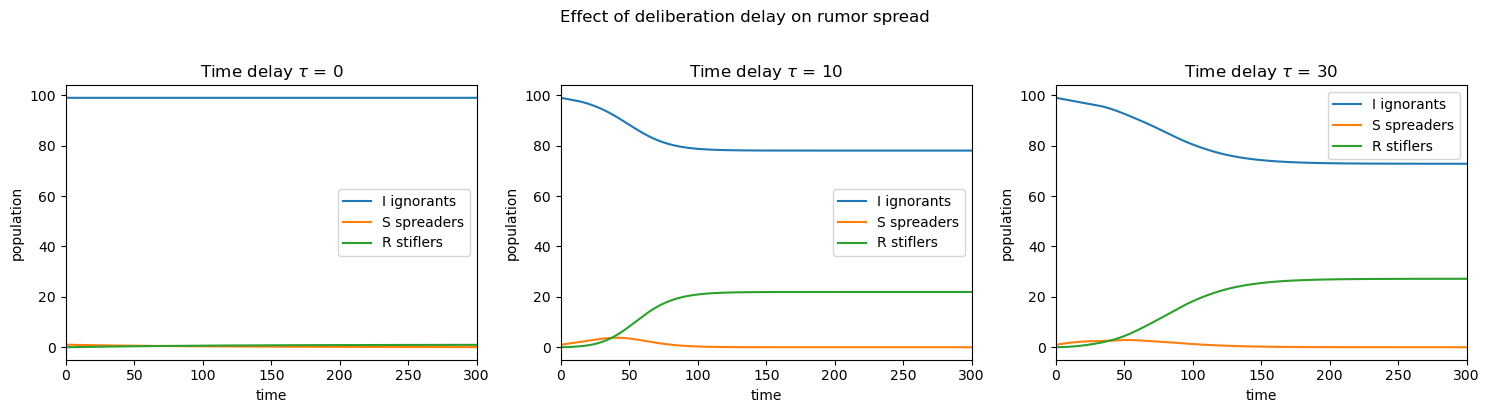

tau =   0: total exposure = 1.0%
tau =  10: total exposure = 21.9%
tau =  30: total exposure = 27.2%


In [3]:
# PLOT 4: time delay extension
# scipy has no built-in DDE solver so we use Euler with history

def simulate_dde(tau, beta, alpha, N, I0, S0, T=500, dt=0.1):
    steps = int(T / dt)
    delay_steps = int(tau / dt)

    I = np.zeros(steps)
    S = np.zeros(steps)
    I[0] = I0
    S[0] = S0

    for k in range(1, steps):
        # lagged values: use history or initial condition if before start
        if k - delay_steps >= 0:
            I_lag = I[k - delay_steps]
            S_lag = S[k - delay_steps]
        else:
            I_lag = I0   # before t=0, assume initial condition
            S_lag = S0

        dI = -beta * I_lag * S_lag
        dS =  beta * I_lag * S_lag - alpha * S[k-1] * (N - I[k-1])

        I[k] = I[k-1] + dt * dI
        S[k] = max(0, S[k-1] + dt * dS)   # S can't go negative

    t = np.linspace(0, T, steps)
    return t, I, S

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
taus = [0, 10, 30]

for ax, tau in zip(axes, taus):
    t, I, S = simulate_dde(tau, beta, alpha, N, I0=99, S0=1)
    R = N - I - S
    ax.plot(t, I, label='I ignorants')
    ax.plot(t, S, label='S spreaders')
    ax.plot(t, R, label='R stiflers')
    ax.set_title(f'Time delay $\\tau$ = {tau}')
    ax.set_xlabel('time')
    ax.set_ylabel('population')
    ax.set_xlim(0, 300)
    ax.legend()

plt.suptitle('Effect of deliberation delay on rumor spread', y=1.02)
plt.tight_layout()
plt.show()

# print total exposure for each tau
for tau in taus:
    t, I, S = simulate_dde(tau, beta, alpha, N, I0=99, S0=1)
    exposure = (N - I[-1]) / N * 100
    print(f"tau = {tau:>3}: total exposure = {exposure:.1f}%")

In [4]:
from scipy.optimize import fsolve


# at equilibrium I* = Ic = 90.9
I_star = Ic

def characteristic_equations(vars, tau):
    omega = vars[0]
    # real part = 0
    real = (alpha + beta)*I_star - alpha*N - beta*I_star*np.cos(omega*tau)
    # imaginary part = 0
    imag = omega - beta*I_star*np.sin(omega*tau)
    return [real, imag]

# sweep tau and find where imaginary axis crossing occurs
taus = np.linspace(0.1, 100, 500)
crossings = []

for tau in taus:
    try:
        sol = fsolve(characteristic_equations, x0=[0.01], args=(tau,),
                     full_output=True)
        omega_sol = sol[0][0]
        residual = np.max(np.abs(sol[1]['fvec']))
        if residual < 1e-10 and omega_sol > 0:
            crossings.append((tau, omega_sol))
    except:
        pass

if crossings:
    tau_star = crossings[0][0]
    print(f"Critical delay tau* = {tau_star:.2f}")
else:
    print("No crossing found in range: equilibrium stable for all tau tested")

No crossing found in range: equilibrium stable for all tau tested
